# Bankruptcy Prediction Study Case - Taiwan Central Bank

**Notebook Outline**
1. Problem Understanding
2. Data Loading & Data Understanding
3. Exploratory Data Analysis
4. Data Preparation (Cleaning, Transformation, Handling Imbalance)
5. Modelling (CatBoost / XGBoost)
6. Evaluation
7. Feature Importance


# Load Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from catboost import CatBoostClassifier, Pool
from xgboost import XGBClassifier
import seaborn as sns

# Load Dataset

In [ ]:
df = pd.read_csv('/content/data-bank.csv')
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


# Data Understanding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [ ]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


# Exploratory Data Analysis

In [ ]:
# Ambil hanya kolom numerik
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

# Hitung korelasi dengan target
corr_with_target = df[numeric_cols].corr()['Bankrupt?'].abs().sort_values(ascending=False)

# Ambil 5 fitur teratas (selain target)
top_features = corr_with_target.index[1:6]  # index[0] = Bankrupt?

print("Top 5 fitur berdasarkan korelasi ke Bankrupt?:")
print(top_features)

Top 5 fitur berdasarkan korelasi ke Bankrupt?:
Index([' Net Income to Total Assets',
       ' ROA(A) before interest and % after tax',
       ' ROA(B) before interest and depreciation after tax',
       ' ROA(C) before interest and depreciation before interest',
       ' Net worth/Assets'],
      dtype='object')


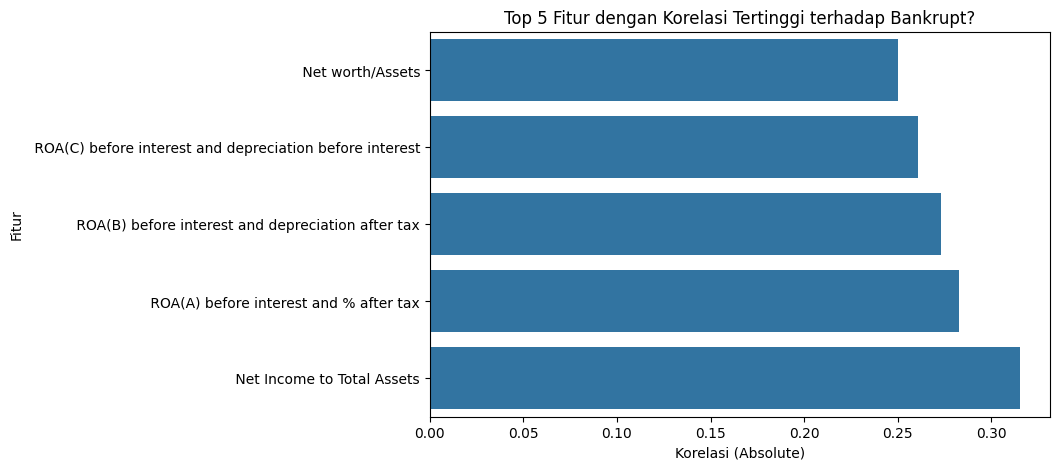

In [ ]:
# Buat dataframe untuk plot
top_corr_df = corr_with_target[top_features].sort_values()

plt.figure(figsize=(8,5))
sns.barplot(x=top_corr_df.values, y=top_corr_df.index, orient='h')
plt.title("Top 5 Fitur dengan Korelasi Tertinggi terhadap Bankrupt?")
plt.xlabel("Korelasi (Absolute)")
plt.ylabel("Fitur")
plt.show()

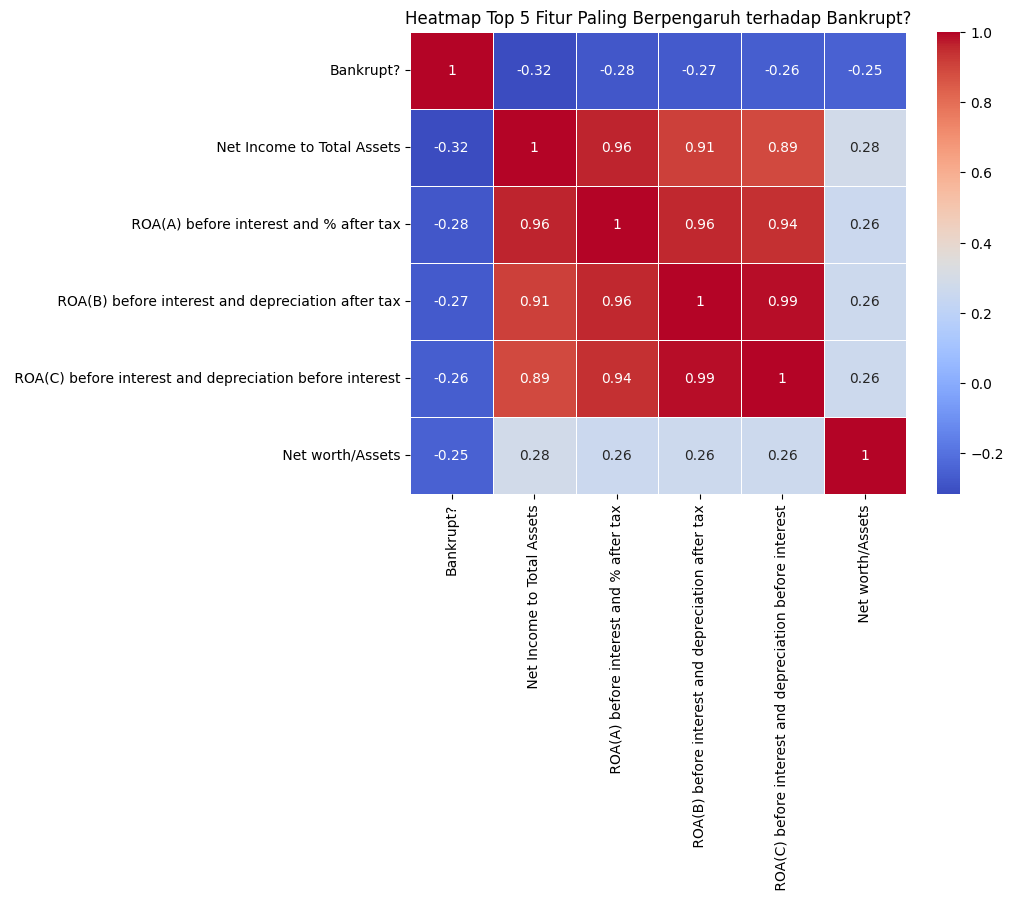

In [ ]:
# Buat subset untuk heatmap
subset_cols = ['Bankrupt?'] + list(top_features)
df_subset = df[subset_cols]

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df_subset.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap Top 5 Fitur Paling Berpengaruh terhadap Bankrupt?")
plt.show()

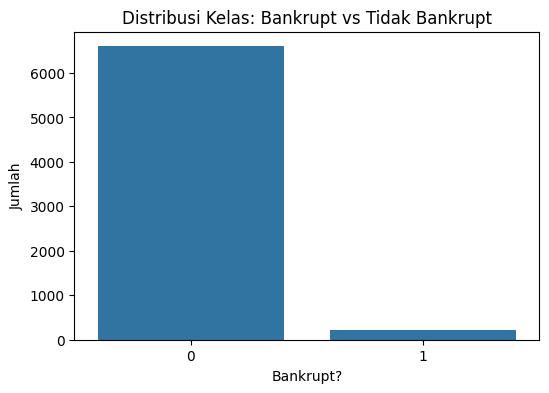

,count
Bankrupt?,
0,6599
1,220


In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["Bankrupt?"])
plt.title("Distribusi Kelas: Bankrupt vs Tidak Bankrupt")
plt.xlabel("Bankrupt?")
plt.ylabel("Jumlah")
plt.show()

df["Bankrupt?"].value_counts()

# Data Preparation

In [ ]:
# Cleaning: Drop duplicates
df = df.drop_duplicates()

# Missing values check
df.isna().sum()

,0
Bankrupt?,0
ROA(C) before interest and depreciation before interest,0
ROA(A) before interest and % after tax,0
ROA(B) before interest and depreciation after tax,0
Operating Gross Margin,0
...,...
Liability to Equity,0
Degree of Financial Leverage (DFL),0
Interest Coverage Ratio (Interest expense to EBIT),0
Net Income Flag,0


In [ ]:
# Feature & Target
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Handling imbalance using class weight for CatBoost
neg, pos = y.value_counts()[0], y.value_counts()[1]
scale_pos_weight = neg / pos
print('Scale pos weight:', scale_pos_weight)

Scale pos weight: 29.995454545454546


# Modeling

In [ ]:
# CatBoost
model_cb = CatBoostClassifier(
    iterations=800,
    learning_rate=0.03,
    depth=8,
    eval_metric='AUC',
    scale_pos_weight=scale_pos_weight,
    random_seed=42,
    verbose=100
)

# XGBoost
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss'
)

model_cb.fit(X_train, y_train, eval_set=(X_test, y_test))
model_xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)])

0:	test: 0.8524363	best: 0.8524363 (0)	total: 295ms	remaining: 3m 55s
100:	test: 0.9436295	best: 0.9440427 (97)	total: 12.9s	remaining: 1m 29s
200:	test: 0.9475723	best: 0.9476240 (198)	total: 25.3s	remaining: 1m 15s
300:	test: 0.9485709	best: 0.9493802 (267)	total: 34.2s	remaining: 56.7s
400:	test: 0.9486398	best: 0.9493802 (267)	total: 43.2s	remaining: 43s
500:	test: 0.9496384	best: 0.9497073 (495)	total: 52.7s	remaining: 31.4s
600:	test: 0.9504132	best: 0.9506543 (543)	total: 1m	remaining: 20.1s
700:	test: 0.9498967	best: 0.9506543 (543)	total: 1m 9s	remaining: 9.85s
799:	test: 0.9493802	best: 0.9506543 (543)	total: 1m 18s	remaining: 0us

bestTest = 0.95065427
bestIteration = 543

Shrink model to first 544 iterations.
[0]	validation_0-logloss:0.65392
[1]	validation_0-logloss:0.61869
[2]	validation_0-logloss:0.58751
[3]	validation_0-logloss:0.55881
[4]	validation_0-logloss:0.53287
[5]	validation_0-logloss:0.50940
[6]	validation_0-logloss:0.48715
[7]	validation_0-logloss:0.46629
[8]	v

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

# Evaluation

Confusion Matrix:


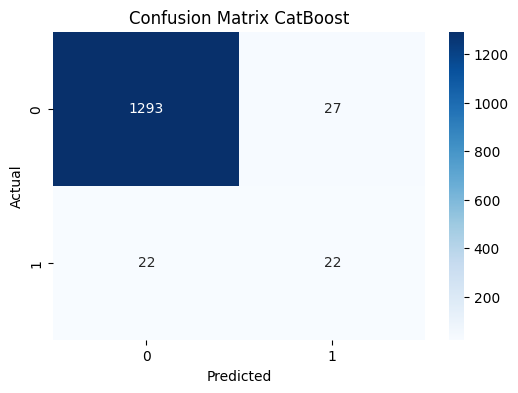

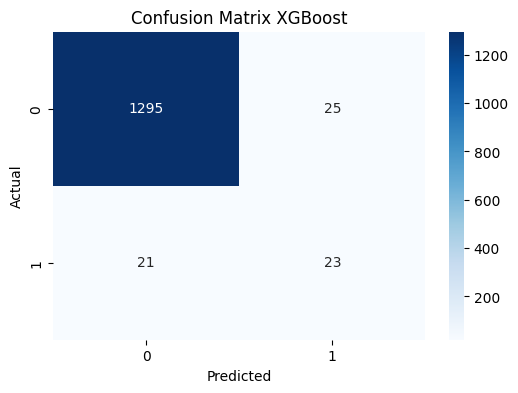

In [ ]:
pred_cb = model_cb.predict(X_test)
pred_proba_cb = model_cb.predict_proba(X_test)[:,1]

pred_xgb = model_xgb.predict(X_test)
pred_proba_xgb = model_xgb.predict_proba(X_test)[:,1]

cm_cb = confusion_matrix(y_test, pred_cb)
cm_xgb = confusion_matrix(y_test, pred_xgb)

print("Confusion Matrix:")
plt.figure(figsize=(6,4))
sns.heatmap(cm_cb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n\n")

plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, pred_cb))
print(classification_report(y_test, pred_xgb))

print("ROC-AUC Score:", roc_auc_score(y_test, pred_proba_cb))
print("ROC-AUC Score:", roc_auc_score(y_test, pred_proba_xgb))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.45      0.50      0.47        44

    accuracy                           0.96      1364
   macro avg       0.72      0.74      0.73      1364
weighted avg       0.97      0.96      0.97      1364

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1320
           1       0.48      0.52      0.50        44

    accuracy                           0.97      1364
   macro avg       0.73      0.75      0.74      1364
weighted avg       0.97      0.97      0.97      1364

ROC-AUC Score: 0.9506542699724517
ROC-AUC Score: 0.9601584022038567


# Feature Importance

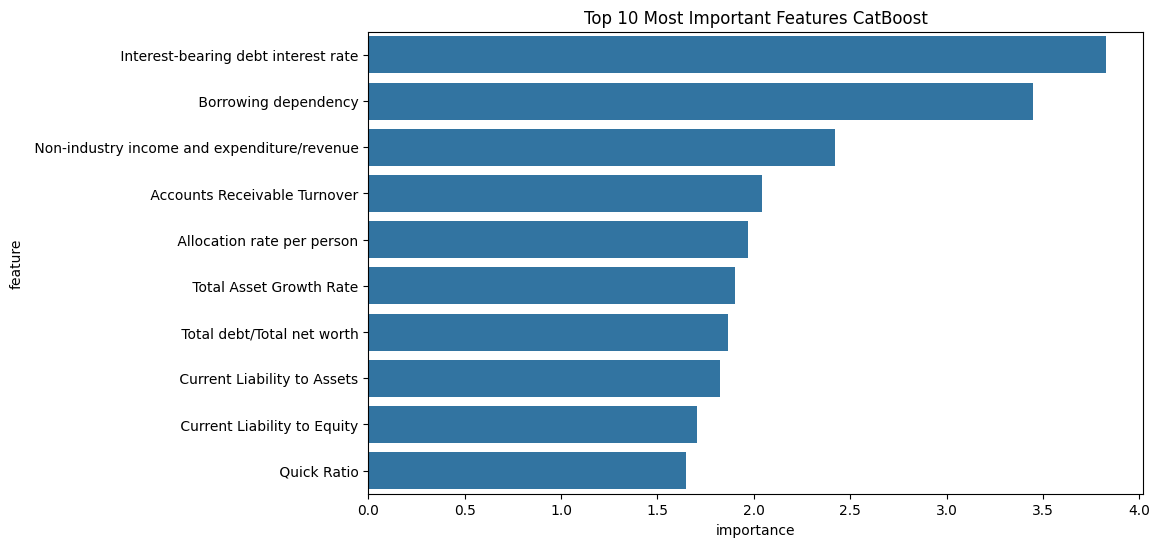

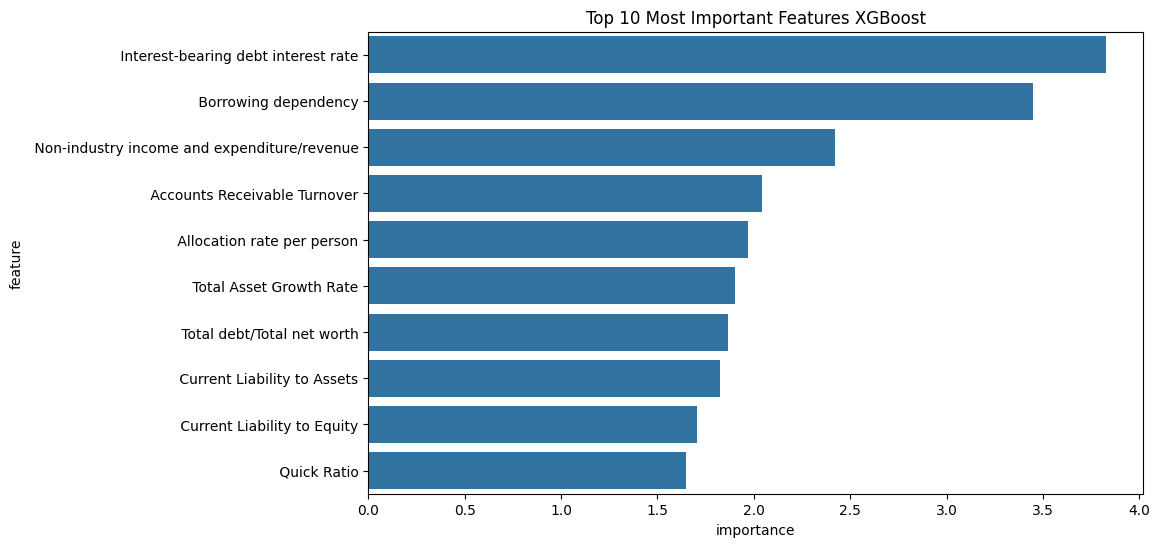

In [ ]:
feature_importance = model_cb.get_feature_importance()
fi_df = pd.DataFrame({'feature': X.columns, 'importance': feature_importance})
fi_df = fi_df.sort_values('importance', ascending=False)
fi_df.head(10)

feature_importance_xgb = model_xgb.feature_importances_
fi_df_xgb = pd.DataFrame({'feature': X.columns, 'importance': feature_importance})
fi_df_xgb = fi_df.sort_values('importance', ascending=False)
fi_df_xgb.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=fi_df.head(10), x='importance', y='feature')
plt.title('Top 10 Most Important Features CatBoost')
plt.show()

print("\n\n")

plt.figure(figsize=(10,6))
sns.barplot(data=fi_df_xgb.head(10), x='importance', y='feature')
plt.title('Top 10 Most Important Features XGBoost')
plt.show()